## Initial Model Training

In [38]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

# basic algebra and system libraries
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path as path
import pandas as pd
import gc
from tqdm.notebook import tqdm
import datetime
import seaborn as sns

# signal discrete fourier transform and loading
import scipy.signal as signal
import scipy.io.wavfile as wavfile
import scipy.fft as fft

# audio preprocessing, cross-validation, and others
from sklearn.base import TransformerMixin, BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_score, recall_score

# construction of convolutional neural network
import keras
import keras.optimizers as optimizers
import keras.layers as layers
import keras.losses as losses
import keras.metrics as metrics
import keras.regularizers as regularizers
from tensorflow.keras import Input
from tensorflow.keras.callbacks import TensorBoard

# audio analysis
import librosa
import librosa.display

# processing speedup using GPU
import tensorflow as tf

# for working with images 
import cv2

In [9]:
tf.config.set_visible_devices([], 'GPU')
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


W0000 00:00:1733841366.315789    7721 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [10]:
# Load audio data paths and metadata
metadata = []
data_dir = os.path.join("..", "data", "raw")
class_1_speakers = ['f1', 'f7', 'f8', 'm3', 'm6', 'm8']

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".wav"):
            speaker_id = file.split('_')[0]
            label = 1 if speaker_id in class_1_speakers else 0
            metadata.append({
                'path': os.path.join(root, file),
                'label': label
            })

metadata_df = pd.DataFrame(metadata)
metadata_df.head()
len(metadata)

101

In [11]:
def load_and_split_audio(file_path, target_sr=16000, segment_length=1):
    # Load audio
    audio, sr = librosa.load(file_path, sr=target_sr)
    total_length = len(audio) / sr
    segments = []

    # Split audio into segments of length 'segment_length'
    for start in np.arange(0, total_length, segment_length):
        end = start + segment_length
        segment = audio[int(start*sr):int(end*sr)]
        # Pad if the segment is shorter
        if len(segment) < segment_length * sr:
            segment = np.pad(segment, (0, int(segment_length * sr) - len(segment)), mode='constant')
        segments.append(segment)
    return segments

def generate_spectrograms(segments, sr=16000):
    spectrograms = []
    for segment in segments:
        # Generate Mel Spectrogram
        S = librosa.feature.melspectrogram(y=segment, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        S_DB = librosa.power_to_db(S, ref=np.max)
        spectrograms.append(S_DB)
    return spectrograms

# Apply load and split
metadata_df['segments'] = [load_and_split_audio(x) for x in tqdm(metadata_df['path'], desc="Loading and Splitting Audio Files")]
metadata_df = metadata_df.explode('segments')

# Generate spectrograms
metadata_df['spectrograms'] = [generate_spectrograms([x])[0] for x in tqdm(metadata_df['segments'], desc="Generating Spectrograms")]

print(f"Total number of spectrograms generated: {len(metadata_df)}")

Loading and Splitting Audio Files:   0%|          | 0/101 [00:00<?, ?it/s]

Generating Spectrograms:   0%|          | 0/16320 [00:00<?, ?it/s]

Total number of spectrograms generated: 16320


Spectrogram count per class:
label
0    11157
1     5163
Name: count, dtype: int64
0.46275880613068027


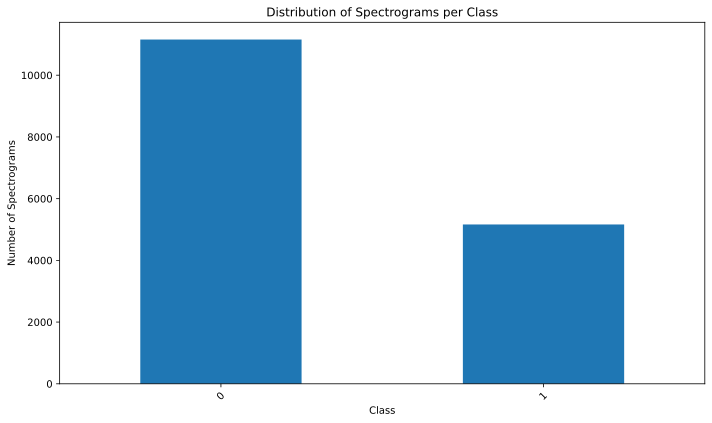

In [12]:
import matplotlib.pyplot as plt

# Count the number of spectrograms per class
class_counts = metadata_df['label'].value_counts()

print("Spectrogram count per class:")
print(class_counts)
print(class_counts[1] / class_counts[0])

# Plot the counts
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')
plt.title("Distribution of Spectrograms per Class")
plt.xlabel("Class")
plt.ylabel("Number of Spectrograms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

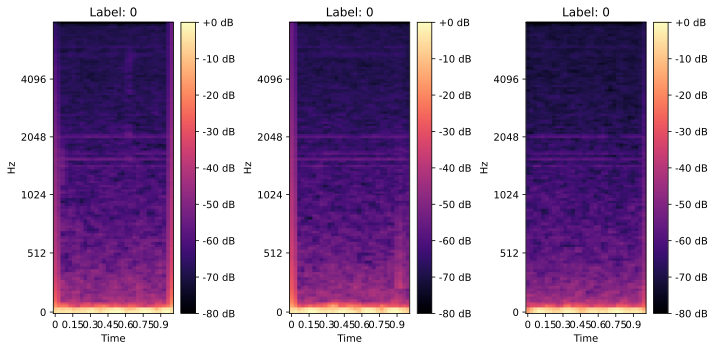

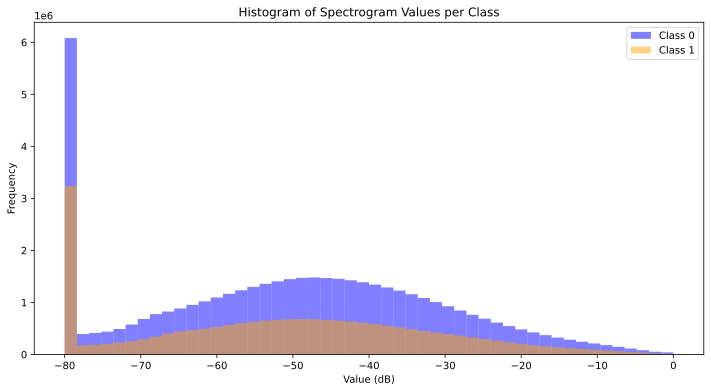

In [13]:
# Plot some example spectrograms
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    librosa.display.specshow(metadata_df.iloc[i]['spectrograms'], sr=16000, hop_length=512, x_axis='time', y_axis='mel')
    plt.title(f"Label: {metadata_df.iloc[i]['label']}")
    plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

# Histogram of spectrogram values per class
class_0_spectrograms = metadata_df[metadata_df['label'] == 0]['spectrograms'].values
class_1_spectrograms = metadata_df[metadata_df['label'] == 1]['spectrograms'].values

# Flatten spectrogram values
class_0_values = np.concatenate([s.ravel() for s in class_0_spectrograms])
class_1_values = np.concatenate([s.ravel() for s in class_1_spectrograms])

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(class_0_values, bins=50, alpha=0.5, label='Class 0', color='blue')
plt.hist(class_1_values, bins=50, alpha=0.5, label='Class 1', color='orange')
plt.title("Histogram of Spectrogram Values per Class")
plt.xlabel("Value (dB)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [14]:
X = np.stack(metadata_df['spectrograms'].values)
X = X[..., np.newaxis]  # Add channel dimension for CNN
Y = metadata_df['label'].values

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create basic CNN model
def create_cnn():
    inputs = Input(shape=(128, 32, 1))
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = create_cnn()

# Set up TensorBoard callback
log_dir = os.path.join("logs", "fit") + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train model
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test),
    callbacks=[tensorboard_callback],
    class_weight=dict(enumerate(compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train)))
)

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 50s 113ms/step - accuracy: 0.5770 - loss: 0.8061 - val_accuracy: 0.7436 - val_loss: 0.5278
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 47s 114ms/step - accuracy: 0.7452 - loss: 0.4937 - val_accuracy: 0.8287 - val_loss: 0.3720
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 45s 111ms/step - accuracy: 0.8204 - loss: 0.3727 - val_accuracy: 0.8410 - val_loss: 0.3590
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 45s 111ms/step - accuracy: 0.8746 - loss: 0.2740 - val_accuracy: 0.9020 - val_loss: 0.2378
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 44s 108ms/step - accuracy: 0.9123 - loss: 0.2003 - val_accuracy: 0.9301 - val_loss: 0.1762
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 45s 110ms/step - accuracy: 0.9427 - loss: 0.1481 - val_accuracy: 0.9366 - val_loss: 0.1571
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.9523 - loss: 0.1156 - val_accuracy: 0.9470 - val_loss: 0.1477
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 45s 110ms/step - accuracy: 0.9717 - loss: 0

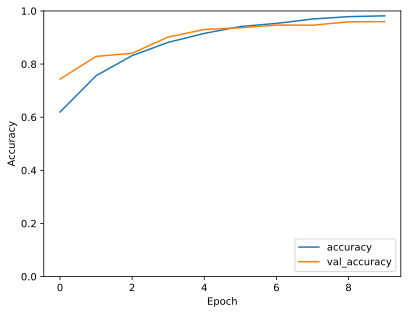

In [15]:
# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [16]:
# Generate predictions and calculate metrics
Y_pred = (model.predict(X_test) > 0.5).astype('int32')

# Calculate accuracy
accuracy = accuracy_score(Y_test, Y_pred)

# Compute the macro-average F1 score
macro_f1 = f1_score(Y_test, Y_pred, average='macro')

# Calculate precision and recall
precision = precision_score(Y_test, Y_pred, average='macro')
recall = recall_score(Y_test, Y_pred, average='macro')

# Output the metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

# Show class report
class_report = classification_report(Y_test, Y_pred)
print(class_report)

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Accuracy: 0.9599
Macro F1: 0.9537
Precision: 0.9494
Recall: 0.9585
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2246
           1       0.92      0.95      0.94      1018

    accuracy                           0.96      3264
   macro avg       0.95      0.96      0.95      3264
weighted avg       0.96      0.96      0.96      3264



## Interpretability

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Feature maps for layer: conv2d


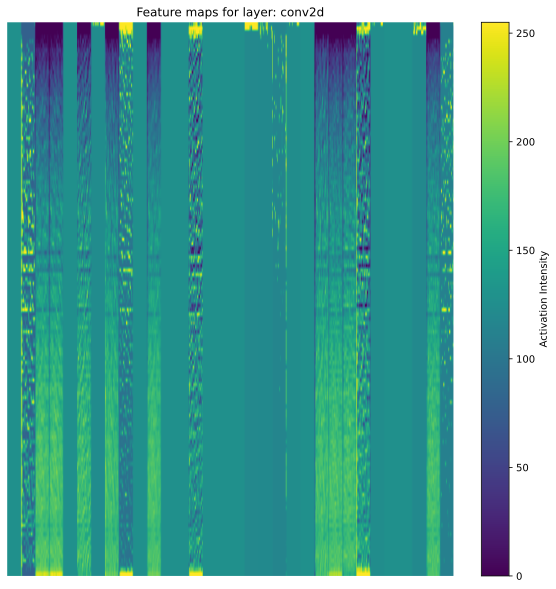

Feature maps for layer: conv2d_1


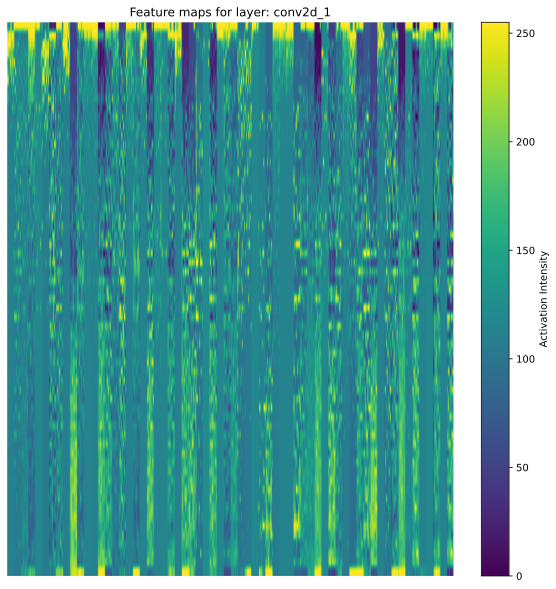

Feature maps for layer: conv2d_2


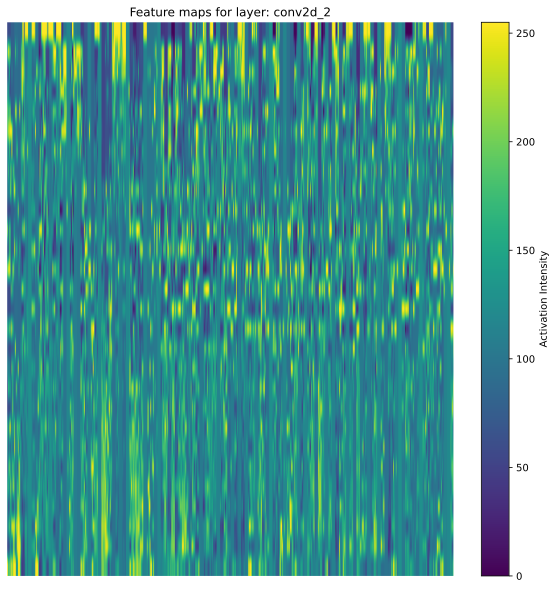

In [27]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Create a sub-model to extract feature maps
layer_names = [layer.name for layer in model.layers if 'conv' in layer.name]
feature_map_model = Model(inputs=model.input, outputs=[model.get_layer(name).output for name in layer_names])

# Select a test sample
test_sample = X_test[0][np.newaxis, ...]

# Get feature maps
feature_maps = feature_map_model.predict(test_sample)

# Plot feature maps
for layer_name, fmap in zip(layer_names, feature_maps):
    print(f"Feature maps for layer: {layer_name}")
    n_filters = fmap.shape[-1]
    fmap_height, fmap_width = fmap.shape[1], fmap.shape[2]

    display_grid = np.zeros((fmap_height, fmap_width * n_filters))

    for i in range(n_filters):
        fmap_slice = fmap[0, :, :, i]
        fmap_slice -= fmap_slice.mean()
        fmap_slice /= (fmap_slice.std() + 1e-5)
        fmap_slice *= 64
        fmap_slice += 128
        fmap_slice = np.clip(fmap_slice, 0, 255).astype('uint8')
        display_grid[:, i * fmap_width: (i + 1) * fmap_width] = fmap_slice

    # Display the grid with a color bar
    plt.figure(figsize=(10, 10))
    plt.title(f"Feature maps for layer: {layer_name}")
    img = plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.colorbar(img, label="Activation Intensity")
    plt.axis('off')
    plt.show()

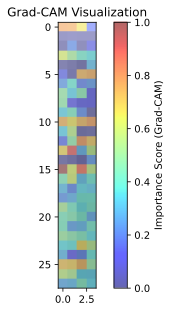

In [25]:
import tensorflow as tf
import numpy as np

def compute_grad_cam(model, input_image, layer_name):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(input_image)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    guided_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(guided_grads, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

# Generate Grad-CAM heatmap for a sample
test_sample = X_test[0][np.newaxis, ...]
heatmap = compute_grad_cam(model, test_sample, layer_name='conv2d_2')

# Overlay heatmap on the spectrogram
plt.imshow(X_test[0, :, :, 0], cmap='gray', alpha=0.8)  # Background spectrogram
img = plt.imshow(heatmap, alpha=0.6, cmap='jet')  # Heatmap overlay
plt.colorbar(img, label="Importance Score (Grad-CAM)")
plt.title("Grad-CAM Visualization")
plt.show()

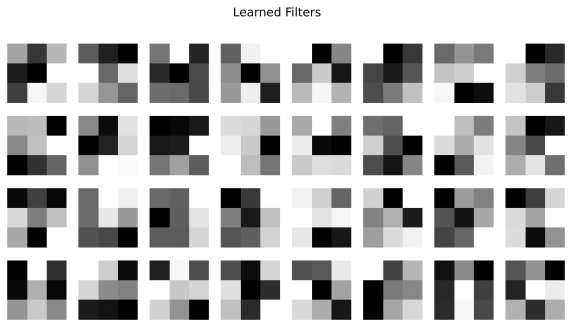

In [22]:
weights, biases = model.layers[1].get_weights()  # Get weights of the first Conv2D layer
n_filters = weights.shape[-1]

plt.figure(figsize=(10, 5))
for i in range(n_filters):
    plt.subplot(4, 8, i + 1)
    plt.imshow(weights[:, :, 0, i], cmap='gray')
    plt.axis('off')
plt.suptitle("Learned Filters")
plt.show()

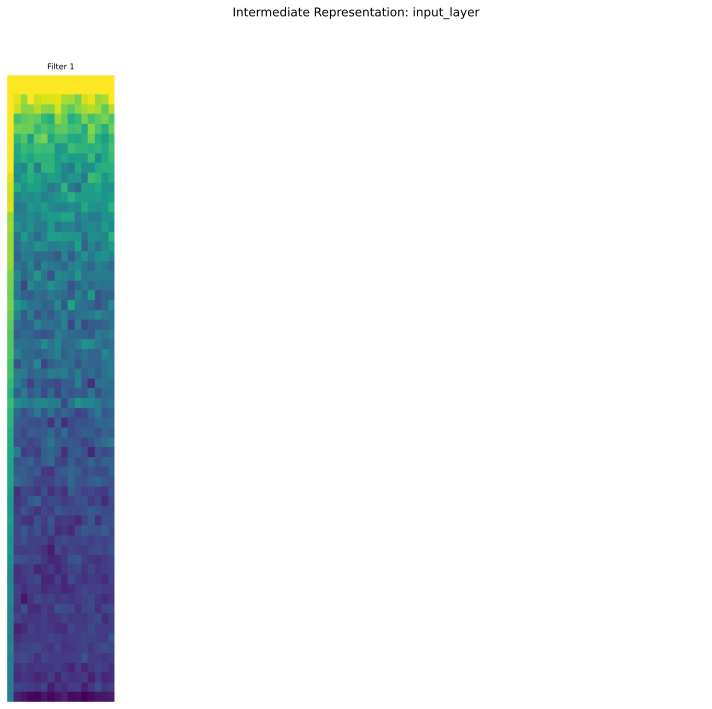

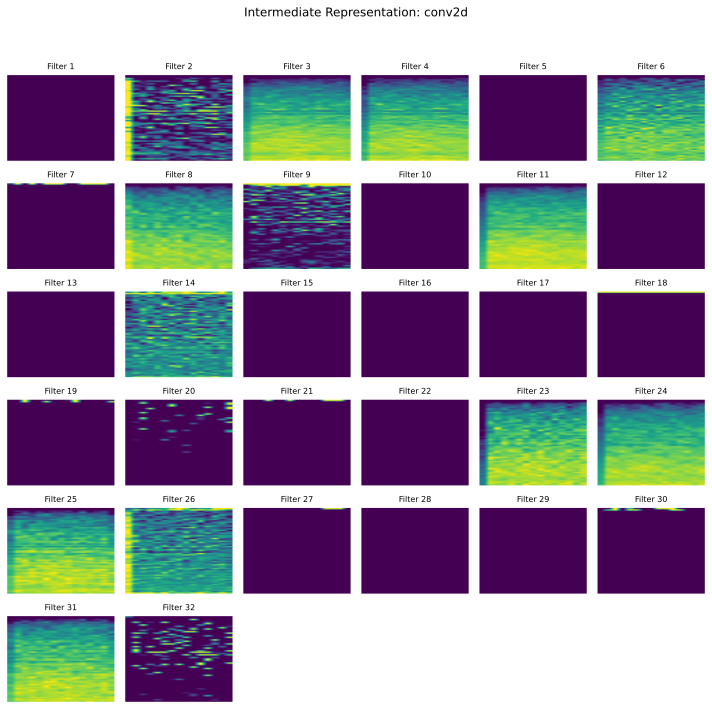

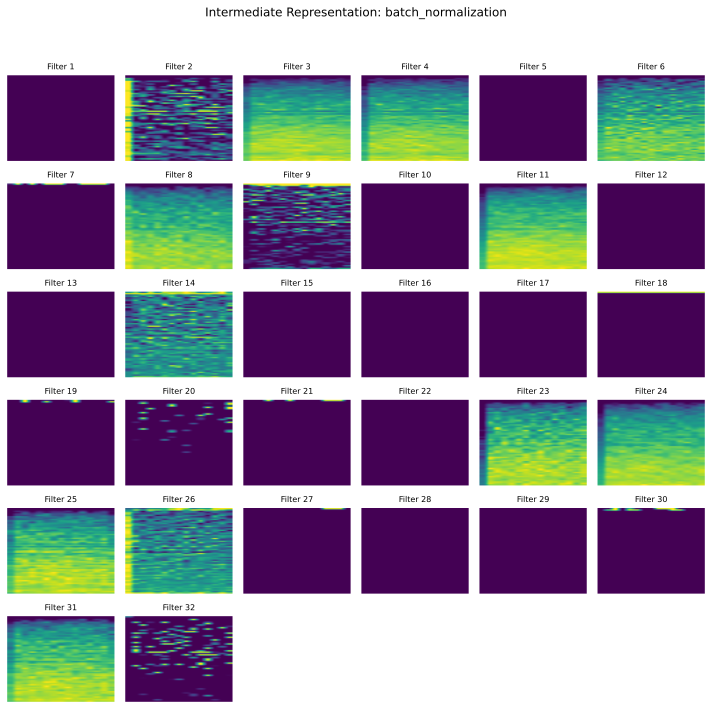

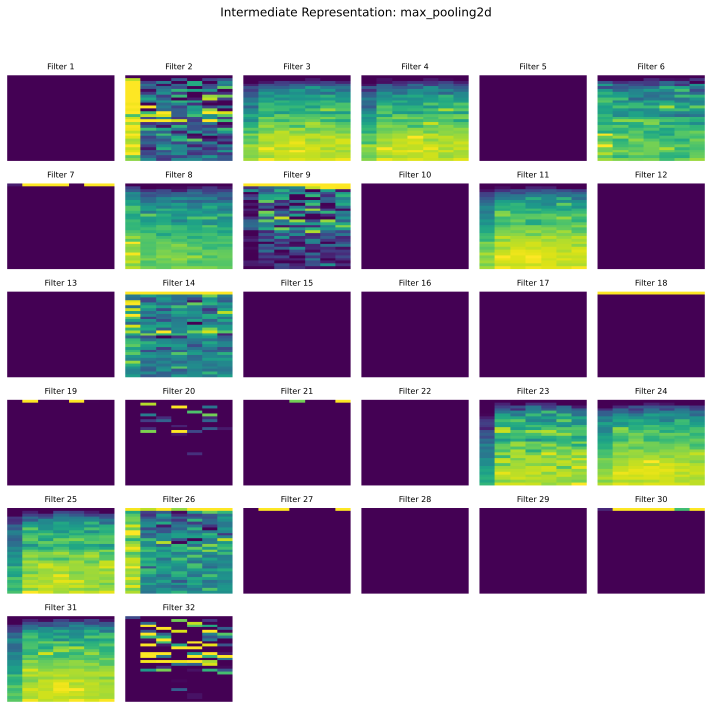

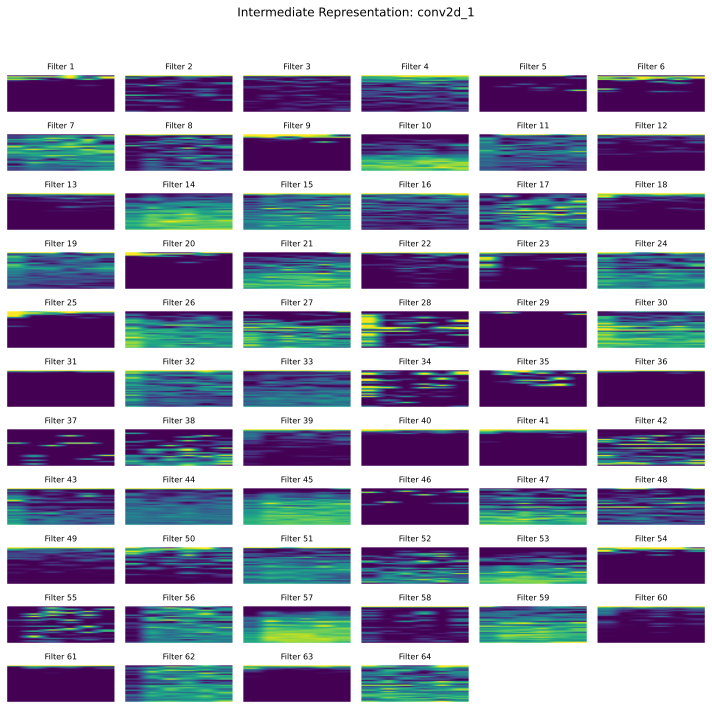

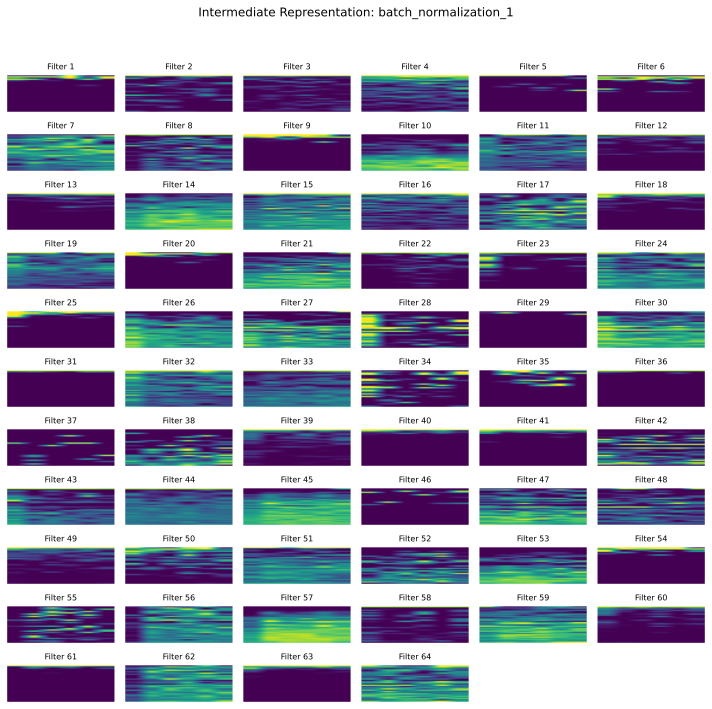

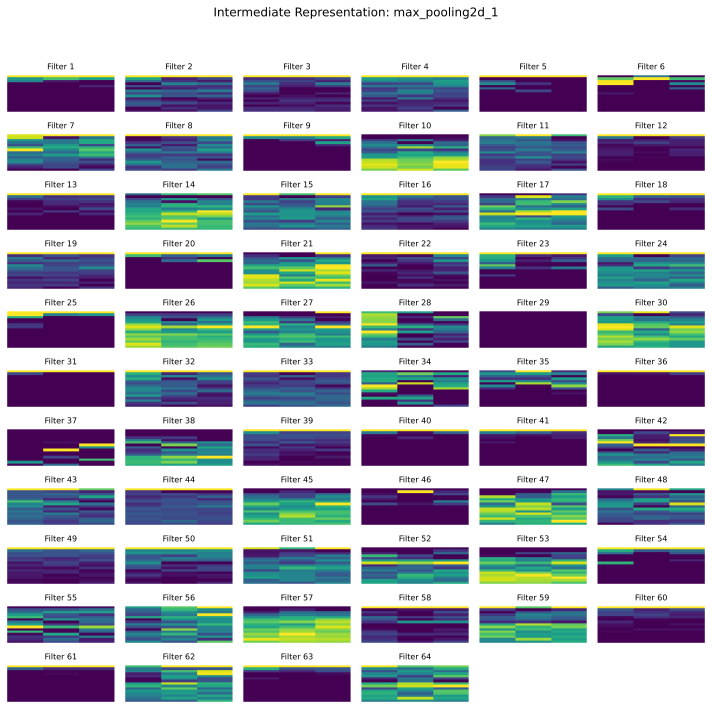

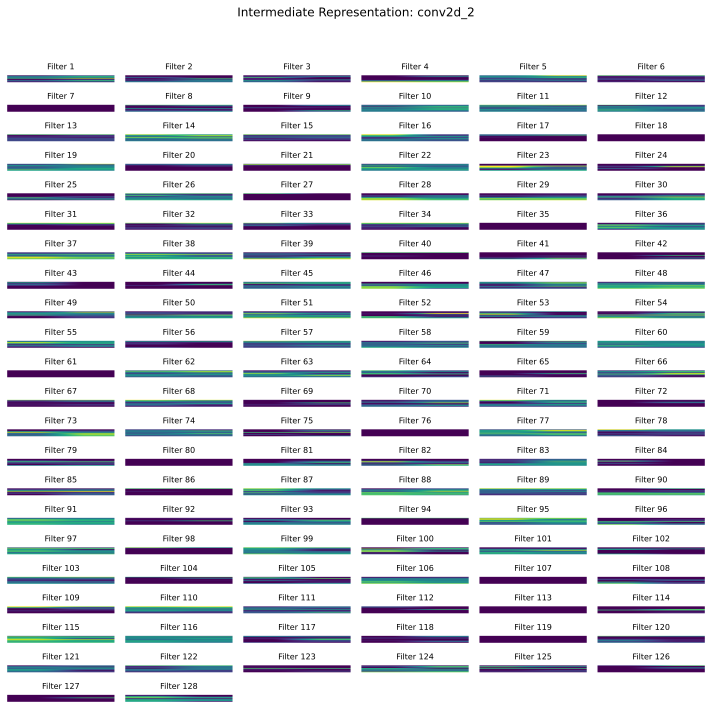

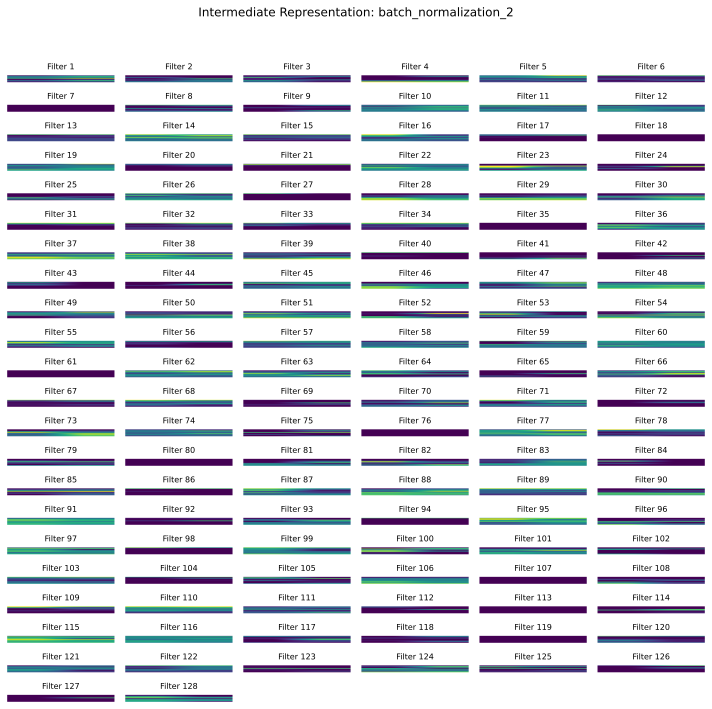

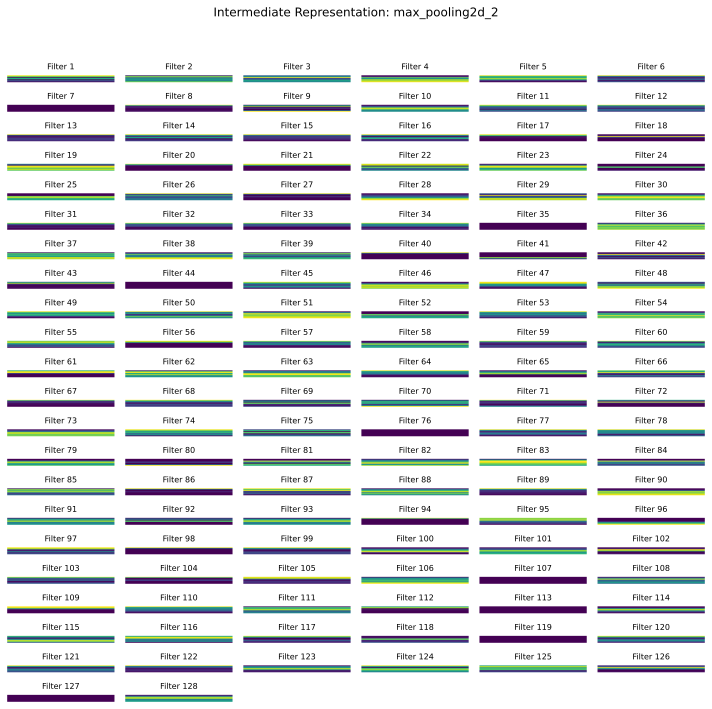

In [39]:
# Plot intermediate representations
for layer, output in zip(model.layers, intermediate_outputs):
    if len(output.shape) == 4:  # Only visualize 2D feature maps
        n_filters = output.shape[-1]
        fmap_height, fmap_width = output.shape[1], output.shape[2]

        # Determine grid layout for compact display
        grid_cols = 6  # Number of columns in the grid
        grid_rows = math.ceil(n_filters / grid_cols)

        # Create a smaller grid plot
        fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(10, 10))
        fig.suptitle(f"Intermediate Representation: {layer.name}", fontsize=12)
        axes = axes.flatten()

        for i in range(n_filters):
            feature_map = output[0, :, :, i]
            
            # Normalize and resize the feature map for compactness
            feature_map -= feature_map.mean()
            feature_map /= (feature_map.std() + 1e-5)
            feature_map = np.clip(feature_map * 64 + 128, 0, 255).astype('uint8')
            
            # Resize feature map for a smaller display
            small_feature_map = cv2.resize(feature_map, (fmap_width // 2, fmap_height // 2), interpolation=cv2.INTER_NEAREST)

            # Plot in the grid
            axes[i].imshow(small_feature_map, aspect='auto', cmap='viridis')
            axes[i].axis('off')
            axes[i].set_title(f"Filter {i+1}", fontsize=8)

        # Turn off unused subplots
        for j in range(n_filters, len(axes)):
            axes[j].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


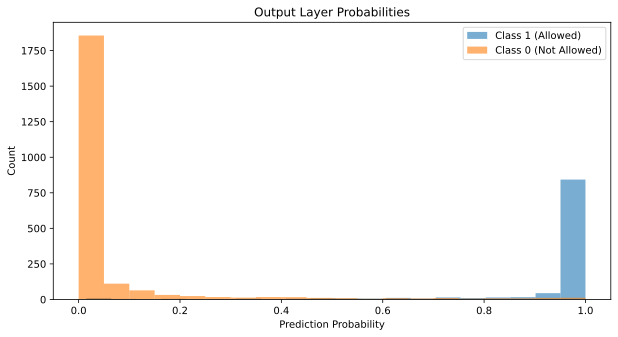

In [29]:
# Predict probabilities for the test set
probs = model.predict(X_test)

# Visualize predictions
plt.figure(figsize=(10, 5))
plt.hist(probs[Y_test == 1], bins=20, alpha=0.6, label="Class 1 (Allowed)")
plt.hist(probs[Y_test == 0], bins=20, alpha=0.6, label="Class 0 (Not Allowed)")
plt.xlabel("Prediction Probability")
plt.ylabel("Count")
plt.title("Output Layer Probabilities")
plt.legend()
plt.show()

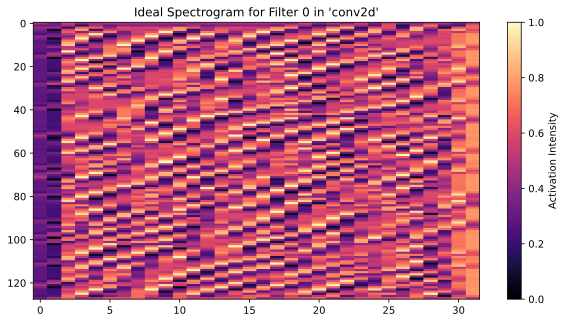

In [30]:
import tensorflow as tf

def generate_ideal_spectrogram(model, target_layer, target_filter, input_shape):
    # Random noise as starting point
    input_image = tf.random.uniform((1, *input_shape), minval=0, maxval=1)

    # Build a model that outputs the target layer
    layer_model = Model(inputs=model.input, outputs=model.get_layer(target_layer).output)

    # Optimization loop
    for _ in range(100):  # Number of iterations
        with tf.GradientTape() as tape:
            tape.watch(input_image)
            layer_output = layer_model(input_image)
            loss = tf.reduce_mean(layer_output[..., target_filter])  # Maximize activation of target filter

        # Compute gradients
        grads = tape.gradient(loss, input_image)
        grads /= (tf.sqrt(tf.reduce_mean(tf.square(grads))) + 1e-5)

        # Update input image
        input_image += grads * 0.1  # Learning rate for gradient ascent

    # Normalize spectrogram
    spectrogram = input_image.numpy()[0]
    spectrogram -= spectrogram.min()
    spectrogram /= spectrogram.max()
    return spectrogram

# Generate spectrogram for the first filter in the first Conv2D layer
ideal_spectrogram = generate_ideal_spectrogram(model, "conv2d", 0, (128, 32, 1))

# Visualize
plt.figure(figsize=(10, 5))
plt.imshow(ideal_spectrogram.squeeze(), aspect='auto', cmap='magma')
plt.title("Ideal Spectrogram for Filter 0 in 'conv2d'")
plt.colorbar(label="Activation Intensity")
plt.show()